# 03 — Pretrained ResNet18 Encoder Autoencoder

Train two variants of `ResNetAutoencoder` (pretrained ResNet18 backbone) on the cable anomaly dataset and compare them:

| Variant | `freeze_encoder` | Trainable params |
|---------|-----------------|-----------------|
| **Frozen** | `True` | Bottleneck + decoder only |
| **Fine-tune** | `False` | Entire network |

Architecture (`src/models_pretrained.py`):
- **Encoder**: ResNet18 (ImageNet pretrained), output `[B, 256, 16, 16]`
- **Bottleneck**: Conv2d(256 → 256) + BN + LeakyReLU
- **Decoder**: 4 × ConvTranspose2d + Conv2d projection → `[B, 3, 256, 256]` + Sigmoid

Note: inputs are normalized to ImageNet statistics before entering the encoder, while reconstruction losses are computed against original `[0,1]` images.

## 1. Imports & Setup

In [28]:
import sys
sys.path.insert(0, '../src')

import copy
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from utils import set_seed, CHECKPOINTS_DIR
from dataset import get_dataloaders
from models_pretrained import ResNetAutoencoder
from masking import (
    generate_cable_mask,
    masked_mae_loss,
    masked_ssim_loss,
    compute_masked_error_map,
)

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_MASKING = False

# ImageNet stats for pretrained ResNet encoder inputs.
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)

def normalize_for_encoder(x):
    mean = IMAGENET_MEAN.to(x.device)
    std = IMAGENET_STD.to(x.device)
    return (x - mean) / std

print(f'Using device: {DEVICE}')
print(f'Background masking: {USE_MASKING}')

Using device: cuda
Background masking: False


## 2. Data Loading

In [29]:
BATCH_SIZE = 16

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE, val_split=0.15, seed=42
)

n_train = len(train_loader.dataset)
n_val   = len(val_loader.dataset)
n_test  = len(test_loader.dataset)

print(f'Train samples : {n_train}')
print(f'Val   samples : {n_val}')
print(f'Test  samples : {n_test}')
print(f'Train + Val   : {n_train + n_val}  (expected 224)')

Train samples : 191
Val   samples : 33
Test  samples : 150
Train + Val   : 224  (expected 224)


In [30]:
# Inspect a batch shape
sample_batch = next(iter(train_loader))
print(f'Batch shape : {sample_batch.shape}')  # [16, 3, 256, 256]
print(f'Dtype       : {sample_batch.dtype}')
print(f'Min / Max   : {sample_batch.min():.3f} / {sample_batch.max():.3f}')

Batch shape : torch.Size([16, 3, 256, 256])
Dtype       : torch.float32
Min / Max   : 0.000 / 1.000


## 3. Model Setup

Two `ResNetAutoencoder` instances are created — one with the encoder frozen and one with full fine-tuning.

In [31]:
def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_frozen   = ResNetAutoencoder(bottleneck_width=256, freeze_encoder=True).to(DEVICE)
model_finetune = ResNetAutoencoder(bottleneck_width=256, freeze_encoder=False).to(DEVICE)

print(f'Frozen    — trainable params: {count_trainable(model_frozen):,}')
print(f'Fine-tune — trainable params: {count_trainable(model_finetune):,}')

# Shape smoke test (use normalized encoder input path).
with torch.no_grad():
    dummy = torch.rand(2, 3, 256, 256).to(DEVICE)
    out   = model_frozen(normalize_for_encoder(dummy))
print(f'\nSmoke test — input: {tuple(dummy.shape)}, output: {tuple(out.shape)}')

Frozen    — trainable params: 1,573,251
Fine-tune — trainable params: 12,749,763

Smoke test — input: (2, 3, 256, 256), output: (2, 3, 256, 256)


## 4. Training

A shared `train_model()` helper runs the training loop with early stopping, then returns the trained model and loss history.

In [32]:
from torchmetrics.functional import structural_similarity_index_measure

NUM_EPOCHS = 50
LR         = 1e-4
MAE_WEIGHT = 0.4 # TODO: try 0.4 next
PATIENCE   = 15


def train_model(model, checkpoint_name):
    """Train model with masked MAE+SSIM loss and early stopping."""
    optimizer = optim.Adam(model.parameters(), lr=LR)

    train_losses, val_losses = [], []
    best_val_loss  = float('inf')
    best_epoch     = 0
    wait           = 0
    best_state     = copy.deepcopy(model.state_dict())

    for epoch in range(1, NUM_EPOCHS + 1):
        # --- Train ---
        model.train()
        running = 0.0
        running_mae = 0.0
        running_ssim = 0.0
        for imgs in train_loader:
            imgs = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            optimizer.zero_grad()
            recon = model(imgs_enc)

            if USE_MASKING:
                mask      = generate_cable_mask(imgs)
                loss_mae  = masked_mae_loss(recon, imgs, mask)
                loss_ssim = masked_ssim_loss(recon, imgs, mask)
            else:
                loss_mae  = torch.nn.functional.l1_loss(recon, imgs)
                loss_ssim = 1.0 - structural_similarity_index_measure(
                    recon, imgs, data_range=1.0
                )

            loss = MAE_WEIGHT * loss_mae + (1.0 - MAE_WEIGHT) * loss_ssim
            loss.backward()
            optimizer.step()

            running += loss.item() * imgs.size(0)
            running_mae += loss_mae.item() * imgs.size(0)
            running_ssim += loss_ssim.item() * imgs.size(0)

        train_loss = running / len(train_loader.dataset)
        train_mae = running_mae / len(train_loader.dataset)
        train_ssim_d = running_ssim / len(train_loader.dataset)

        # --- Validate ---
        model.eval()
        running_val = 0.0
        running_val_mae = 0.0
        running_val_ssim = 0.0
        with torch.no_grad():
            for imgs in val_loader:
                imgs  = imgs.to(DEVICE)
                imgs_enc = normalize_for_encoder(imgs)
                recon = model(imgs_enc)
                if USE_MASKING:
                    mask     = generate_cable_mask(imgs)
                    val_mae  = masked_mae_loss(recon, imgs, mask)
                    val_ssim = masked_ssim_loss(recon, imgs, mask)
                else:
                    val_mae  = torch.nn.functional.l1_loss(recon, imgs)
                    val_ssim = 1.0 - structural_similarity_index_measure(
                        recon, imgs, data_range=1.0
                    )

                v_loss = MAE_WEIGHT * val_mae + (1.0 - MAE_WEIGHT) * val_ssim
                running_val += v_loss.item() * imgs.size(0)
                running_val_mae += val_mae.item() * imgs.size(0)
                running_val_ssim += val_ssim.item() * imgs.size(0)

        val_loss = running_val / len(val_loader.dataset)
        val_mae = running_val_mae / len(val_loader.dataset)
        val_ssim_d = running_val_ssim / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_epoch    = epoch
            wait          = 0
            best_state    = copy.deepcopy(model.state_dict())
        else:
            wait += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{checkpoint_name}] Epoch {epoch:3d}/{NUM_EPOCHS}  '
                  f'train={train_loss:.6f}  val={val_loss:.6f}')
            print(f'    components: train_mae={train_mae:.6f}, train_(1-ssim)={train_ssim_d:.6f}  '
                  f'val_mae={val_mae:.6f}, val_(1-ssim)={val_ssim_d:.6f}')

        if wait >= PATIENCE:
            print(f'Early stopping at epoch {epoch} '
                  f'(best epoch={best_epoch}, best_val={best_val_loss:.6f})')
            break

    model.load_state_dict(best_state)
    CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), CHECKPOINTS_DIR / checkpoint_name)
    print(f'Saved checkpoint -> {CHECKPOINTS_DIR / checkpoint_name}')
    return model, {'train': train_losses, 'val': val_losses}

In [33]:
print('=== Training: Frozen encoder ===')
model_frozen,   losses_frozen   = train_model(model_frozen,   'resnet_frozen.pth')

print('\n=== Training: Fine-tuned encoder ===')
model_finetune, losses_finetune = train_model(model_finetune, 'resnet_finetune.pth')

=== Training: Frozen encoder ===
[resnet_frozen.pth] Epoch   1/50  train=0.596302  val=0.524666
    components: train_mae=0.245405, train_(1-ssim)=0.830233  val_mae=0.214610, val_(1-ssim)=0.731369
[resnet_frozen.pth] Epoch  10/50  train=0.502365  val=0.473278
    components: train_mae=0.230061, train_(1-ssim)=0.683901  val_mae=0.207209, val_(1-ssim)=0.650657
[resnet_frozen.pth] Epoch  20/50  train=0.495089  val=0.465238
    components: train_mae=0.225953, train_(1-ssim)=0.674514  val_mae=0.203367, val_(1-ssim)=0.639819
[resnet_frozen.pth] Epoch  30/50  train=0.489562  val=0.461558
    components: train_mae=0.221786, train_(1-ssim)=0.668080  val_mae=0.200093, val_(1-ssim)=0.635867
[resnet_frozen.pth] Epoch  40/50  train=0.487883  val=0.458089
    components: train_mae=0.218403, train_(1-ssim)=0.667536  val_mae=0.195975, val_(1-ssim)=0.632832
[resnet_frozen.pth] Epoch  50/50  train=0.466788  val=0.437018
    components: train_mae=0.193069, train_(1-ssim)=0.649268  val_mae=0.171719, val_(

## 5. Loss Curves

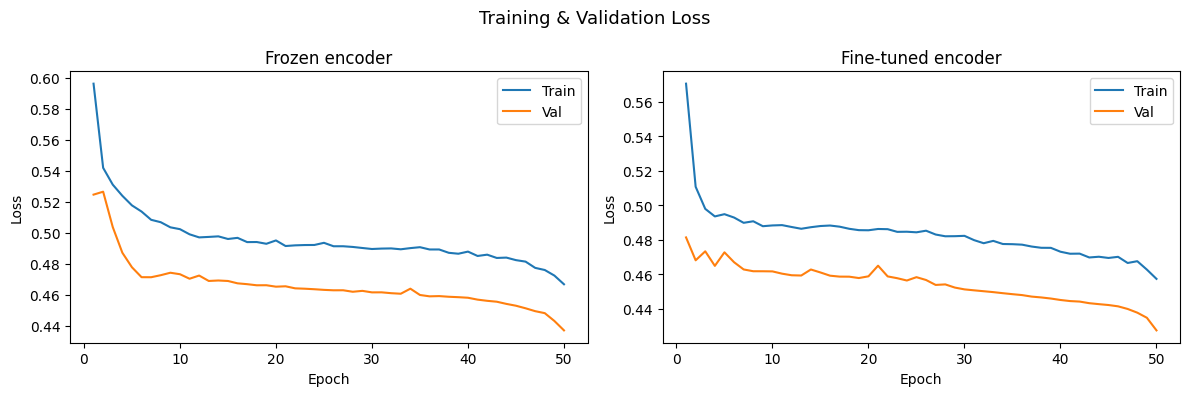

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, losses, title in [
    (axes[0], losses_frozen,   'Frozen encoder'),
    (axes[1], losses_finetune, 'Fine-tuned encoder'),
]:
    epochs = range(1, len(losses['train']) + 1)
    ax.plot(epochs, losses['train'], label='Train')
    ax.plot(epochs, losses['val'],   label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('Training & Validation Loss', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Image-level Evaluation

### 6.1 Compute Anomaly Scores on Test Set

In [50]:
def compute_scores(model, loader_test, loader_val):
    """Return (mae_scores, combined_scores, all_labels, val_combined_errors) arrays."""
    mae_scores, ssim_dissim_scores, all_labels = [], [], []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader_test:
            imgs  = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            recon = model(imgs_enc)

            if USE_MASKING:
                mask    = generate_cable_mask(imgs)
                px_err  = torch.abs(recon - imgs) * mask
                n_cable = mask.sum(dim=(1, 2, 3)) * imgs.shape[1]
                batch_mae = px_err.sum(dim=(1, 2, 3)) / (n_cable + 1e-8)
            else:
                batch_mae = torch.mean(torch.abs(recon - imgs), dim=(1, 2, 3))
            mae_scores.extend(batch_mae.cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                if USE_MASKING:
                    m_i    = generate_cable_mask(imgs[i:i+1])
                    ssim_i = structural_similarity_index_measure(
                        recon[i:i+1] * m_i, imgs[i:i+1] * m_i, data_range=1.0
                    ).item()
                else:
                    ssim_i = structural_similarity_index_measure(
                        recon[i:i+1], imgs[i:i+1], data_range=1.0
                    ).item()
                ssim_dissim_scores.append(1.0 - ssim_i)

            all_labels.extend(labels.tolist())

    mae_scores          = np.array(mae_scores)
    ssim_dissim_scores  = np.array(ssim_dissim_scores)
    combined_scores     = MAE_WEIGHT * mae_scores + (1.0 - MAE_WEIGHT) * ssim_dissim_scores
    all_labels          = np.array(all_labels)

    # Val-set combined errors for threshold calibration
    val_mae_list, val_ssim_list = [], []
    with torch.no_grad():
        for imgs in loader_val:
            imgs  = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            recon = model(imgs_enc)
            if USE_MASKING:
                mask    = generate_cable_mask(imgs)
                px_err  = torch.abs(recon - imgs) * mask
                n_cable = mask.sum(dim=(1, 2, 3)) * imgs.shape[1]
                b_mae   = px_err.sum(dim=(1, 2, 3)) / (n_cable + 1e-8)
            else:
                b_mae = torch.mean(torch.abs(recon - imgs), dim=(1, 2, 3))
            val_mae_list.extend(b_mae.cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                if USE_MASKING:
                    m_i = generate_cable_mask(imgs[i:i+1])
                    s_i = structural_similarity_index_measure(
                        recon[i:i+1] * m_i, imgs[i:i+1] * m_i, data_range=1.0
                    ).item()
                else:
                    s_i = structural_similarity_index_measure(
                        recon[i:i+1], imgs[i:i+1], data_range=1.0
                    ).item()
                val_ssim_list.append(1.0 - s_i)

    val_mae  = np.array(val_mae_list)
    val_ssim = np.array(val_ssim_list)
    val_combined = MAE_WEIGHT * val_mae + (1.0 - MAE_WEIGHT) * val_ssim

    return mae_scores, combined_scores, all_labels, val_combined


print('Computing scores for frozen model...')
mae_f, comb_f, labels, val_comb_f = compute_scores(model_frozen, test_loader, val_loader)

print('Computing scores for fine-tuned model...')
mae_ft, comb_ft, _,      val_comb_ft = compute_scores(model_finetune, test_loader, val_loader)

n_normal = int((labels == 0).sum())
n_anom   = int((labels == 1).sum())
print(f'\nTest set: {n_normal} normal, {n_anom} anomalous')

for tag, mae_s, comb_s in [('Frozen',    mae_f,  comb_f),
                            ('Fine-tune', mae_ft, comb_ft)]:
    print(f'\n[{tag}]')
    print(f'  MAE      — normal: {mae_s[labels==0].mean():.4f}, anom: {mae_s[labels==1].mean():.4f}')
    print(f'  Combined — normal: {comb_s[labels==0].mean():.4f}, anom: {comb_s[labels==1].mean():.4f}')

Computing scores for frozen model...


Computing scores for frozen model...


d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Computing scores for frozen model...


d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Computing scores for fine-tuned model...

Test set: 58 normal, 92 anomalous

[Frozen]
  MAE      — normal: 0.1681, anom: 0.1698
  Combined — normal: 0.4191, anom: 0.4258

[Fine-tune]
  MAE      — normal: 0.1549, anom: 0.1576
  Combined — normal: 0.4094, anom: 0.4157


### 6.2 Full Test Set Evaluation (ROC-AUC, F1, etc.)


[Frozen] policy=max-f1
  Selected quantile=0.20, threshold=0.420171
  ROC-AUC  : 0.6409   PR-AUC: 0.7524
  F1       : 0.6923   Recall: 0.6848   Precision: 0.7000
  Accuracy : 0.6267   Balanced: 0.6096
  FPR      : 0.4655   FNR: 0.3152
  Confusion: TN=31  FP=27  FN=29  TP=63
  Sweep (q, F1, Recall, Precision, FPR):
    q=0.20  f1=0.6923  rec=0.6848  prec=0.7000  fpr=0.4655
    q=0.60  f1=0.1584  rec=0.0870  prec=0.8889  fpr=0.0172
    q=0.65  f1=0.1584  rec=0.0870  prec=0.8889  fpr=0.0172
    q=0.70  f1=0.1400  rec=0.0761  prec=0.8750  fpr=0.0172
    q=0.75  f1=0.1212  rec=0.0652  prec=0.8571  fpr=0.0172
    q=0.80  f1=0.0825  rec=0.0435  prec=0.8000  fpr=0.0172
    q=0.85  f1=0.0426  rec=0.0217  prec=1.0000  fpr=0.0000
    q=0.90  f1=0.0426  rec=0.0217  prec=1.0000  fpr=0.0000
    q=0.95  f1=0.0000  rec=0.0000  prec=0.0000  fpr=0.0000
    q=0.97  f1=0.0000  rec=0.0000  prec=0.0000  fpr=0.0000
    q=0.99  f1=0.0000  rec=0.0000  prec=0.0000  fpr=0.0000

[Fine-tune] policy=max-f1
  Selec


[Frozen] policy=max-f1
  Selected quantile=0.20, threshold=0.420171
  ROC-AUC  : 0.6409   PR-AUC: 0.7524
  F1       : 0.6923   Recall: 0.6848   Precision: 0.7000
  Accuracy : 0.6267   Balanced: 0.6096
  FPR      : 0.4655   FNR: 0.3152
  Confusion: TN=31  FP=27  FN=29  TP=63
  Sweep (q, F1, Recall, Precision, FPR):
    q=0.20  f1=0.6923  rec=0.6848  prec=0.7000  fpr=0.4655
    q=0.60  f1=0.1584  rec=0.0870  prec=0.8889  fpr=0.0172
    q=0.65  f1=0.1584  rec=0.0870  prec=0.8889  fpr=0.0172
    q=0.70  f1=0.1400  rec=0.0761  prec=0.8750  fpr=0.0172
    q=0.75  f1=0.1212  rec=0.0652  prec=0.8571  fpr=0.0172
    q=0.80  f1=0.0825  rec=0.0435  prec=0.8000  fpr=0.0172
    q=0.85  f1=0.0426  rec=0.0217  prec=1.0000  fpr=0.0000
    q=0.90  f1=0.0426  rec=0.0217  prec=1.0000  fpr=0.0000
    q=0.95  f1=0.0000  rec=0.0000  prec=0.0000  fpr=0.0000
    q=0.97  f1=0.0000  rec=0.0000  prec=0.0000  fpr=0.0000
    q=0.99  f1=0.0000  rec=0.0000  prec=0.0000  fpr=0.0000

[Fine-tune] policy=max-f1
  Selec

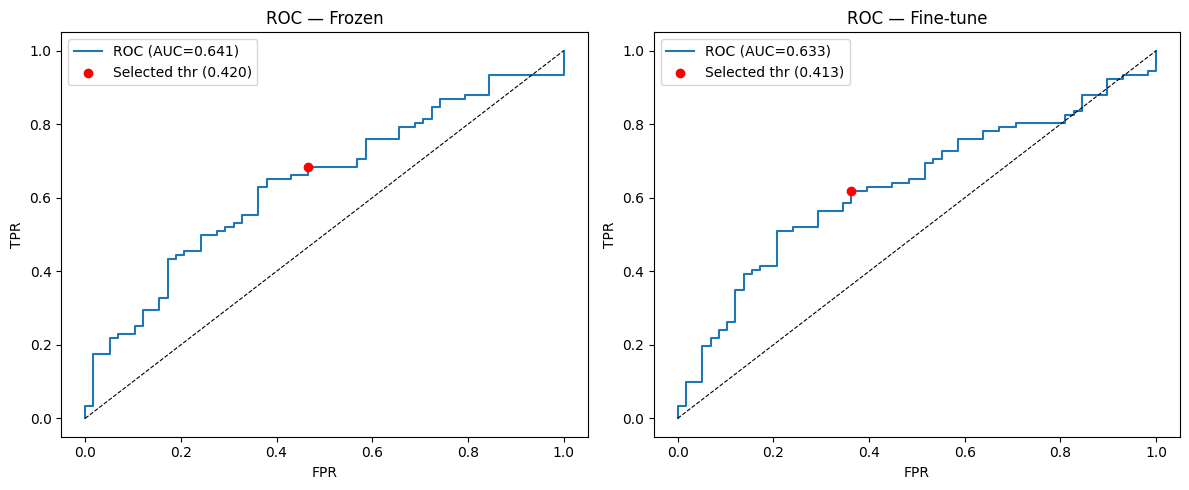

In [55]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix,
    precision_score, recall_score, f1_score,
    accuracy_score, balanced_accuracy_score,
)

# Sweep quantiles and choose operating point by policy.
QUANTILES = [0.2, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
SELECTION_POLICY = 'max-f1'   # 'max-f1' or 'fpr-constrained'
MAX_FPR = 0.10

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

results = {}
for ax, tag, comb_s, val_comb in [
    (axes[0], 'Frozen',    comb_f,  val_comb_f),
    (axes[1], 'Fine-tune', comb_ft, val_comb_ft),
]:
    auc = roc_auc_score(labels, comb_s)
    ap  = average_precision_score(labels, comb_s)

    sweep_rows = []
    for q in QUANTILES:
        threshold = float(np.quantile(val_comb, q))
        preds = (comb_s >= threshold).astype(int)

        prec = precision_score(labels, preds, zero_division=0)
        rec  = recall_score(labels, preds, zero_division=0)
        f1   = f1_score(labels, preds, zero_division=0)
        acc  = accuracy_score(labels, preds)
        bacc = balanced_accuracy_score(labels, preds)
        tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
        fpr_at_thr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
        fnr        = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

        sweep_rows.append({
            'q': q, 'threshold': threshold,
            'f1': f1, 'rec': rec, 'prec': prec,
            'acc': acc, 'bacc': bacc,
            'fpr': fpr_at_thr, 'fnr': fnr,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        })

    if SELECTION_POLICY == 'fpr-constrained':
        feasible = [r for r in sweep_rows if r['fpr'] <= MAX_FPR]
        if feasible:
            selected = max(feasible, key=lambda r: (r['rec'], r['f1'], -r['threshold']))
        else:
            selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))
    else:
        selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))

    threshold = selected['threshold']
    results[tag] = dict(
        auc=auc, ap=ap, f1=selected['f1'], rec=selected['rec'], prec=selected['prec'],
        acc=selected['acc'], bacc=selected['bacc'], fpr=selected['fpr'], fnr=selected['fnr'],
        tn=selected['tn'], fp=selected['fp'], fn=selected['fn'], tp=selected['tp'],
        threshold=threshold, quantile=selected['q'], policy=SELECTION_POLICY,
    )

    print(f'\n[{tag}] policy={SELECTION_POLICY}')
    print(f'  Selected quantile={selected["q"]:.2f}, threshold={threshold:.6f}')
    print(f'  ROC-AUC  : {auc:.4f}   PR-AUC: {ap:.4f}')
    print(f'  F1       : {selected["f1"]:.4f}   Recall: {selected["rec"]:.4f}   Precision: {selected["prec"]:.4f}')
    print(f'  Accuracy : {selected["acc"]:.4f}   Balanced: {selected["bacc"]:.4f}')
    print(f'  FPR      : {selected["fpr"]:.4f}   FNR: {selected["fnr"]:.4f}')
    print(f'  Confusion: TN={selected["tn"]}  FP={selected["fp"]}  FN={selected["fn"]}  TP={selected["tp"]}')
    print('  Sweep (q, F1, Recall, Precision, FPR):')
    for r in sweep_rows:
        print(f'    q={r["q"]:.2f}  f1={r["f1"]:.4f}  rec={r["rec"]:.4f}  prec={r["prec"]:.4f}  fpr={r["fpr"]:.4f}')

    fpr_c, tpr_c, roc_thr = roc_curve(labels, comb_s)
    plot_idx = np.argmin(np.abs(roc_thr - threshold))
    ax.plot(fpr_c, tpr_c, label=f'ROC (AUC={auc:.3f})')
    ax.scatter(fpr_c[plot_idx], tpr_c[plot_idx], color='red', zorder=5,
               label=f'Selected thr ({threshold:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {tag}')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Pixel-level Evaluation

Per-pixel error maps are computed for both models; we report pixel AUROC and mean IoU (sweep over threshold candidates). Overlay visualisation uses the best-performing model.

In [61]:
from sklearn.metrics import roc_auc_score as _roc_auc
from sklearn.metrics import precision_recall_curve as _prc
from utils import GROUND_TRUTH_DIR
from dataset import get_eval_transform
from PIL import Image as PILImage

eval_tf = get_eval_transform()


def pixel_eval(model, tag):
    dataset = test_loader.dataset
    pixel_scores_all, pixel_gt_all = [], []
    err_maps, gt_masks_256 = [], []

    model.eval()
    with torch.no_grad():
        for idx in range(len(dataset)):
            img_path, label = dataset.samples[idx]
            if label == 0:
                continue

            category  = img_path.parent.name
            stem      = img_path.stem
            mask_path = GROUND_TRUTH_DIR / category / f'{stem}_mask.png'

            img_t = eval_tf(PILImage.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
            img_t_enc = normalize_for_encoder(img_t)
            recon = model(img_t_enc)

            if USE_MASKING:
                cable_mask = generate_cable_mask(img_t)
                err_map    = compute_masked_error_map(recon, img_t, cable_mask)
            else:
                err_map = torch.mean(torch.abs(recon - img_t), dim=1).squeeze(0).cpu().numpy()

            gt_raw = np.array(
                PILImage.open(mask_path).convert('L').resize((256, 256), PILImage.NEAREST)
            )
            gt_bin = (gt_raw > 127).astype(np.uint8)

            err_maps.append(err_map)
            gt_masks_256.append(gt_bin)
            pixel_scores_all.extend(err_map.ravel())
            pixel_gt_all.extend(gt_bin.ravel())

    pixel_scores_all = np.array(pixel_scores_all)
    pixel_gt_all     = np.array(pixel_gt_all)

    px_auc = _roc_auc(pixel_gt_all, pixel_scores_all)

    _, _, px_thr = _prc(pixel_gt_all, pixel_scores_all)
    candidates = px_thr[::max(1, len(px_thr) // 200)]
    best_thr, best_miou = 0.0, -1.0
    for thr in candidates:
        ious = []
        for em, gt in zip(err_maps, gt_masks_256):
            pred  = (em >= thr).astype(np.uint8)
            inter = int((pred & gt).sum())
            union = int((pred | gt).sum())
            ious.append(inter / (union + 1e-8))
        m = float(np.mean(ious))
        if m > best_miou:
            best_miou, best_thr = m, float(thr)

    per_image_ious = []
    for em, gt in zip(err_maps, gt_masks_256):
        pred  = (em >= best_thr).astype(np.uint8)
        inter = int((pred & gt).sum())
        union = int((pred | gt).sum())
        per_image_ious.append(inter / (union + 1e-8))
    per_image_ious = np.array(per_image_ious)

    print(f'[{tag}]  Pixel AUROC: {px_auc:.4f}  '
          f'Optimal threshold: {best_thr:.6f}  '
          f'Mean IoU: {per_image_ious.mean():.4f}  '
          f'Std IoU: {per_image_ious.std():.4f}')

    return err_maps, gt_masks_256, per_image_ious, best_thr, px_auc


print('Pixel-level evaluation...')
em_f,  gt_f,  iou_f,  thr_f,  pxauc_f  = pixel_eval(model_frozen,   'Frozen')
em_ft, gt_ft, iou_ft, thr_ft, pxauc_ft = pixel_eval(model_finetune, 'Fine-tune')

Pixel-level evaluation...
[Frozen]  Pixel AUROC: 0.7540  AU-PRO@0.30: 0.3528  Optimal threshold: 0.360927  Mean IoU: 0.1520  Std IoU: 0.1927
[Fine-tune]  Pixel AUROC: 0.7287  AU-PRO@0.30: 0.2934  Optimal threshold: 0.311883  Mean IoU: 0.1100  Std IoU: 0.1408


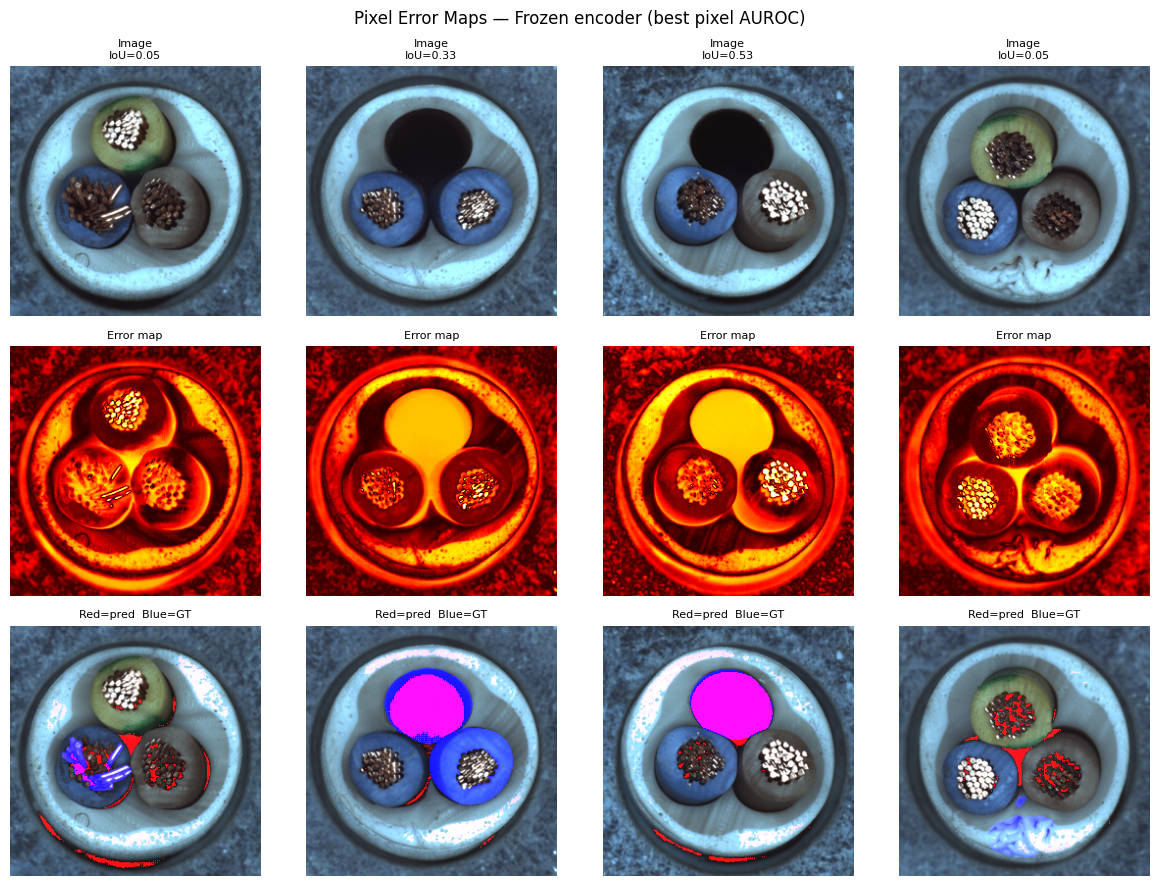

In [57]:
# Overlay visualisation — use best model by pixel AUROC
if pxauc_f >= pxauc_ft:
    best_tag, best_em, best_gt, best_iou, best_thr = 'Frozen',    em_f,  gt_f,  iou_f,  thr_f
else:
    best_tag, best_em, best_gt, best_iou, best_thr = 'Fine-tune', em_ft, gt_ft, iou_ft, thr_ft

anom_paths = [test_loader.dataset.samples[i][0]
              for i in range(len(test_loader.dataset))
              if test_loader.dataset.samples[i][1] == 1]

n_vis      = min(4, len(best_em))
vis_idx    = np.linspace(0, len(best_em) - 1, n_vis, dtype=int)

fig, axes = plt.subplots(3, n_vis, figsize=(3 * n_vis, 9))
for col, vi in enumerate(vis_idx):
    orig = np.array(PILImage.open(anom_paths[vi]).convert('RGB').resize((256, 256)))

    axes[0, col].imshow(orig)
    axes[0, col].set_title(f'Image\nIoU={best_iou[vi]:.2f}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(best_em[vi], cmap='hot')
    axes[1, col].set_title('Error map', fontsize=8)
    axes[1, col].axis('off')

    overlay = orig.copy()
    overlay[(best_em[vi] >= best_thr), 0]      = 255   # red  = predicted
    overlay[best_gt[vi].astype(bool),  2]      = 255   # blue = GT
    axes[2, col].imshow(overlay)
    axes[2, col].set_title('Red=pred  Blue=GT', fontsize=8)
    axes[2, col].axis('off')

fig.suptitle(f'Pixel Error Maps — {best_tag} encoder (best pixel AUROC)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Summary Comparison

In [62]:
print(f"{'Metric':<22} {'Frozen':>12} {'Fine-tune':>12}")
print('-' * 48)
metrics = [
    ('ROC-AUC',     'auc'),
    ('PR-AUC',      'ap'),
    ('F1',          'f1'),
    ('Recall',      'rec'),
    ('Precision',   'prec'),
    ('Balanced Acc','bacc'),
    ('FPR',         'fpr'),
    ('FNR',         'fnr'),
]
for label, key in metrics:
    vf  = results['Frozen'][key]
    vft = results['Fine-tune'][key]
    print(f'{label:<22} {vf:>12.4f} {vft:>12.4f}')

print('-' * 48)
print(f"{'Pixel AUROC':<22} {pxauc_f:>12.4f} {pxauc_ft:>12.4f}")
print(f"{'Mean IoU':<22} {iou_f.mean():>12.4f} {iou_ft.mean():>12.4f}")

Metric                       Frozen    Fine-tune
------------------------------------------------
ROC-AUC                      0.6409       0.6331
PR-AUC                       0.7524       0.7455
F1                           0.6923       0.6627
Recall                       0.6848       0.6087
Precision                    0.7000       0.7273
Balanced Acc                 0.6096       0.6233
FPR                          0.4655       0.3621
FNR                          0.3152       0.3913
------------------------------------------------
Pixel AUROC                  0.7540       0.7287
AU-PRO@0.30                  0.3528       0.2934
Mean IoU                     0.1520       0.1100
